# FFS — testy i klatki syntetyczne

Ten notatnik pracuje **wyłącznie na klatkach syntetycznych** ze znaną prawdą.
Pokazuje, jak testowany jest `pyaraucaria.ffs.FFS`: generator klatek, porównanie
wyników FFS z prawdą i uruchomienie testów. Praca z biblioteką na prawdziwej klatce
z OCA jest w **`ffs_tutorial.ipynb`**.

Konwencje są te same co w tutorialu: `image[y, x]`, `theta` od osi +x przeciwnie do
wskazówek zegara, w [−π/2, π/2); obrazy z `origin="lower"`.

In [1]:
import os
import sys
import warnings

import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import ImageNormalize, ZScaleInterval

# Use the repository version of pyaraucaria and the test helpers in tests/.
# Run this notebook from examples/ inside the repository.
REPO = os.path.abspath("..")
if REPO not in sys.path:
    sys.path.insert(0, REPO)

from pyaraucaria.ffs import FFS
from tests import ffs_synth

warnings.simplefilter("ignore", RuntimeWarning)
%matplotlib inline
# JPEG keeps the notebook small: full-frame noise does not compress as PNG
%config InlineBackend.figure_formats = ["jpeg"]
%config InlineBackend.print_figure_kwargs = {"bbox_inches": "tight", "pil_kwargs": {"quality": 85}}
plt.rcParams["figure.dpi"] = 100


def show(img, ax=None, title=None, extent=None):
    # zscale display, y axis up
    ax = ax or plt.gca()
    norm = ImageNormalize(img, interval=ZScaleInterval())
    ax.imshow(img, origin="lower", cmap="gray", norm=norm, interpolation="nearest",
              extent=extent)
    ax.set_xlabel("x [px]")
    ax.set_ylabel("y [px]")
    if title:
        ax.set_title(title)
    return ax

## 1. Pliki testów

Testy FFS są w czterech plikach w `tests/`:

| plik | co robi |
|---|---|
| `ffs_synth.py` | generator klatek syntetycznych ze znaną prawdą: gwiazdy gaussowskie (eliptyczność, kąt), tło z gradientem, szum Poissona i odczytu, gorące piksele, złe kolumny, ślady satelitów, nasycenie z przelewem. Każdy artefakt jest też zapisywany jako maska `truth["mask_*"]`. Nazwane, deterministyczne scenariusze: `scenario("typical")` itd. |
| `test_ffs_truth.py` | **poprawność**: porównanie wyników FFS z prawdą. Znane błędy są oznaczone `expectedFailure` z opisem `KNOWN BUG`. |
| `test_satellites.py` | **satelity**: wstrzyknięte ślady (jasny, słaby, krótki, przecinające się, przez nasyconą gwiazdę, prawie pionowy, pociąg) — każdy wykryty raz, z dobrą geometrią i maską pokrywającą prawdę; brak fałszywych wykryć na klatkach bez śladu, złych kolumnach, przelewach, słabym wzorze pasów i na prawdziwej jk15c (jeśli dostępna). |
| `test_ffs_regression.py` + `data/ffs_snapshot.json` | **regresja**: wywołania produkcyjne (TOI, Focus, FitsView, filtry `find_stars`, `line_filter`) na wszystkich scenariuszach, porównane z zapisanym stanem. Zamierzoną zmianę zatwierdza się przez `python -m tests.test_ffs_regression --regen`. |

Uruchamianie z katalogu repozytorium:

```bash
python -m unittest tests.test_ffs_truth tests.test_ffs_regression tests.test_satellites
python -m unittest discover tests        # cały zestaw
```

## 2. Klatka syntetyczna i jej prawda

42 gwiazd, gorące piksele: 3, zła kolumna: 512 px, ślad: 3604 px, nasycone: 72 px


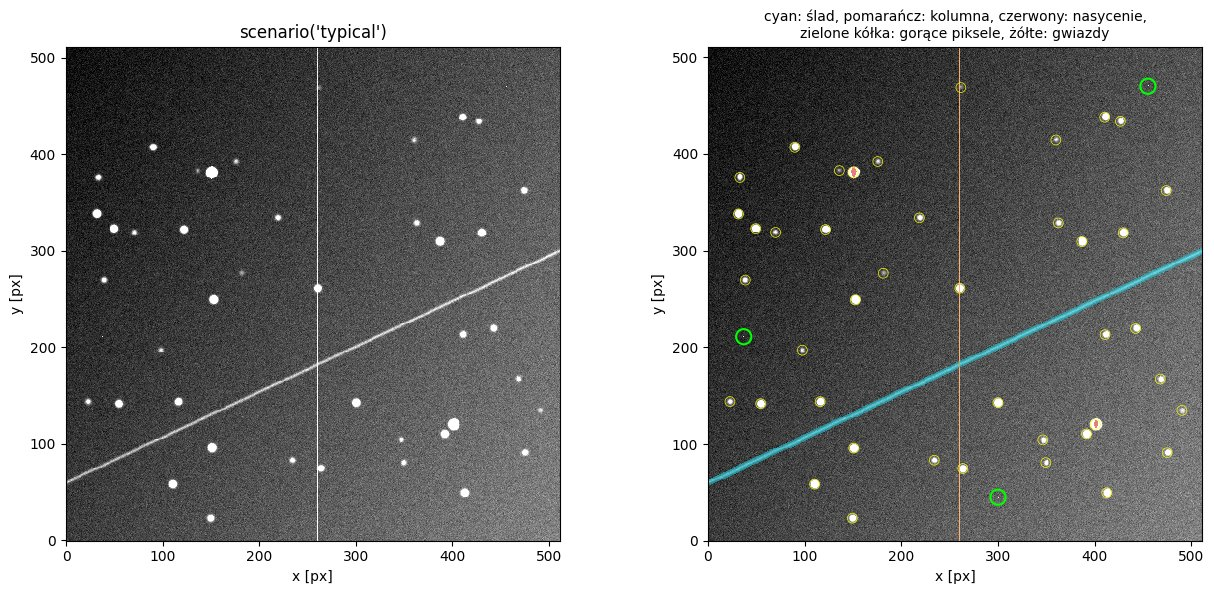

In [2]:
syn = ffs_synth.scenario("typical")
truth = syn.truth
print(f"{len(syn.stars)} gwiazd, gorące piksele: {truth['mask_hot'].sum()}, "
      f"zła kolumna: {truth['mask_bad_column'].sum()} px, ślad: {truth['mask_line'].sum()} px, "
      f"nasycone: {truth['mask_saturated'].sum()} px")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
show(syn.image, axes[0], "scenario('typical')")
show(syn.image, axes[1], "prawda: wstrzyknięte artefakty")
for name, color in [("mask_line", "tab:cyan"), ("mask_bad_column", "tab:orange"),
                    ("mask_saturated", "tab:red")]:
    overlay = np.ma.masked_where(~truth[name], np.ones_like(syn.image))
    axes[1].imshow(overlay, origin="lower", cmap=plt.matplotlib.colors.ListedColormap([color]),
                   alpha=0.6, interpolation="nearest")
hy, hx = np.nonzero(truth["mask_hot"])
axes[1].scatter(hx, hy, s=120, facecolors="none", edgecolors="lime", lw=1.5)
axes[1].scatter([s["x"] for s in syn.stars], [s["y"] for s in syn.stars], s=50,
                facecolors="none", edgecolors="yellow", lw=0.5)
axes[1].set_xlim(0, 511); axes[1].set_ylim(0, 511)
axes[1].set_title("cyan: ślad, pomarańcz: kolumna, czerwony: nasycenie,\n"
                  "zielone kółka: gorące piksele, żółte: gwiazdy", fontsize=10)
plt.tight_layout()

## 3. Gorące piksele a filtry `find_stars()`

Bez filtrów gorące piksele są wykrywane jako „gwiazdy” (zachowanie zgodne z historią,
utrwalone w teście). `max_concentration=0.5` i `min_pixels_above_threshold=5` je odrzucają.

In [3]:
hot_xy = np.argwhere(truth["mask_hot"])[:, ::-1]


def detected_hot(ffs_obj):
    xy = np.column_stack([ffs_obj.coo[:, 1], ffs_obj.coo[:, 0]])
    return sum(np.min(np.hypot(*(xy - h).T)) <= 1 for h in hot_xy)


plain = FFS(syn.image); plain.mk_stats(); plain.find_stars(threshold=5, fwhm=4)
filt = FFS(syn.image); filt.mk_stats()
filt.find_stars(threshold=5, fwhm=4, max_concentration=0.5, min_pixels_above_threshold=5)
print(f"bez filtrów: {len(plain.coo):3d} źródeł, w tym gorących pikseli: {detected_hot(plain)} / {len(hot_xy)}")
print(f"z filtrami:  {len(filt.coo):3d} źródeł, w tym gorących pikseli: {detected_hot(filt)} / {len(hot_xy)}")

bez filtrów: 156 źródeł, w tym gorących pikseli: 3 / 3
z filtrami:  124 źródeł, w tym gorących pikseli: 0 / 3


## 4. Kształt gwiazd: FFS a prawda

Scenariusz `elliptical`: wszystkie gwiazdy mają FWHM osi głównej 5 px, eliptyczność 0,3
i `theta` = 30°. Przed poprawkami FFS dawał tu eliptyczność 0,07 (szum w pudełku),
kąt mierzony od niewłaściwej osi i `theta_spread` ≈ 1 rad.

frame_ellipticity  = 0.301   (prawda 0.300)
theta (mediana)    = 30.0°  (prawda 30.0°)
frame_theta_spread = 0.66°


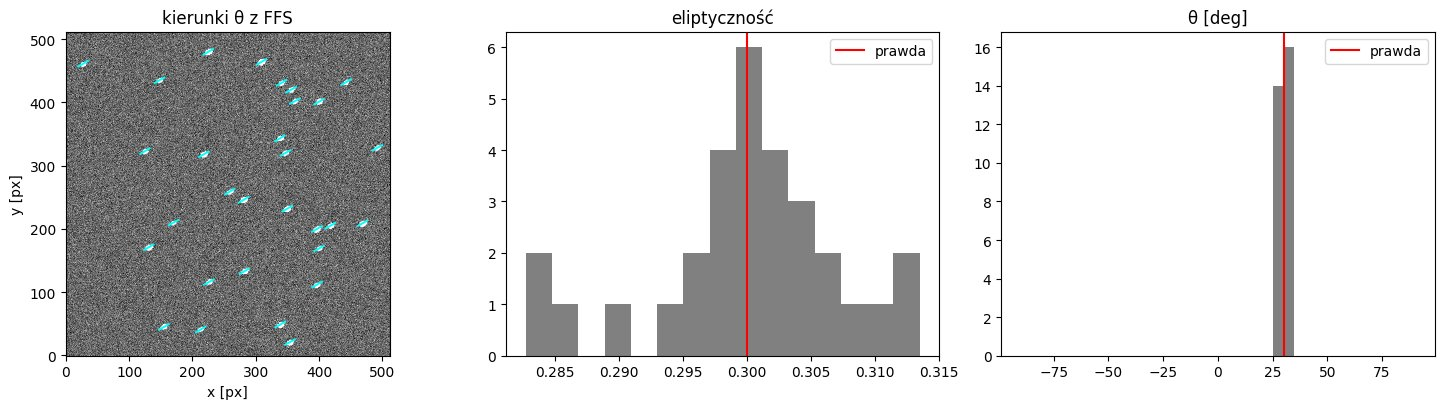

In [4]:
ell = ffs_synth.scenario("elliptical")
fe = FFS(ell.image)
fe.calc_frame_fwhm(threshold=10, fwhm=5, box=15, N_stars=50, clip=4)

print(f"frame_ellipticity  = {fe.frame_ellipticity:.3f}   (prawda 0.300)")
print(f"theta (mediana)    = {np.rad2deg(np.median(fe.theta)):.1f}°  (prawda 30.0°)")
print(f"frame_theta_spread = {np.rad2deg(fe.frame_theta_spread):.2f}°")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
show(ell.image, axes[0], "scenario('elliptical')")
st = fe.stars
axes[0].quiver(st["x"], st["y"], np.cos(st["theta"]), np.sin(st["theta"]), color="cyan",
               angles="xy", headwidth=0, headlength=0, headaxislength=0, pivot="middle",
               scale=25, width=0.006)
axes[0].set_title("kierunki θ z FFS")
axes[1].hist(st["ellipticity"], bins=15, color="0.5"); axes[1].axvline(0.3, color="r", label="prawda")
axes[1].set_title("eliptyczność"); axes[1].legend()
axes[2].hist(np.rad2deg(st["theta"]), bins=36, range=(-90, 90), color="0.5")
axes[2].axvline(30, color="r", label="prawda"); axes[2].set_title("θ [deg]"); axes[2].legend()
plt.tight_layout()

## 5. Satelity — `find_satellites()` na wstrzykniętych śladach

Galeria scenariuszy z `tests/test_satellites.py`. Na każdym obrazie: wykryte odcinki
(czerwony — `satellite`, pomarańczowy — `column`, cyan — `pattern`) i prawda (żółty kontur
— wstrzyknięty ślad). W tytule: pokrycie prawdziwego śladu przez maskę i jaka część maski
leży przy śladzie (czystość).

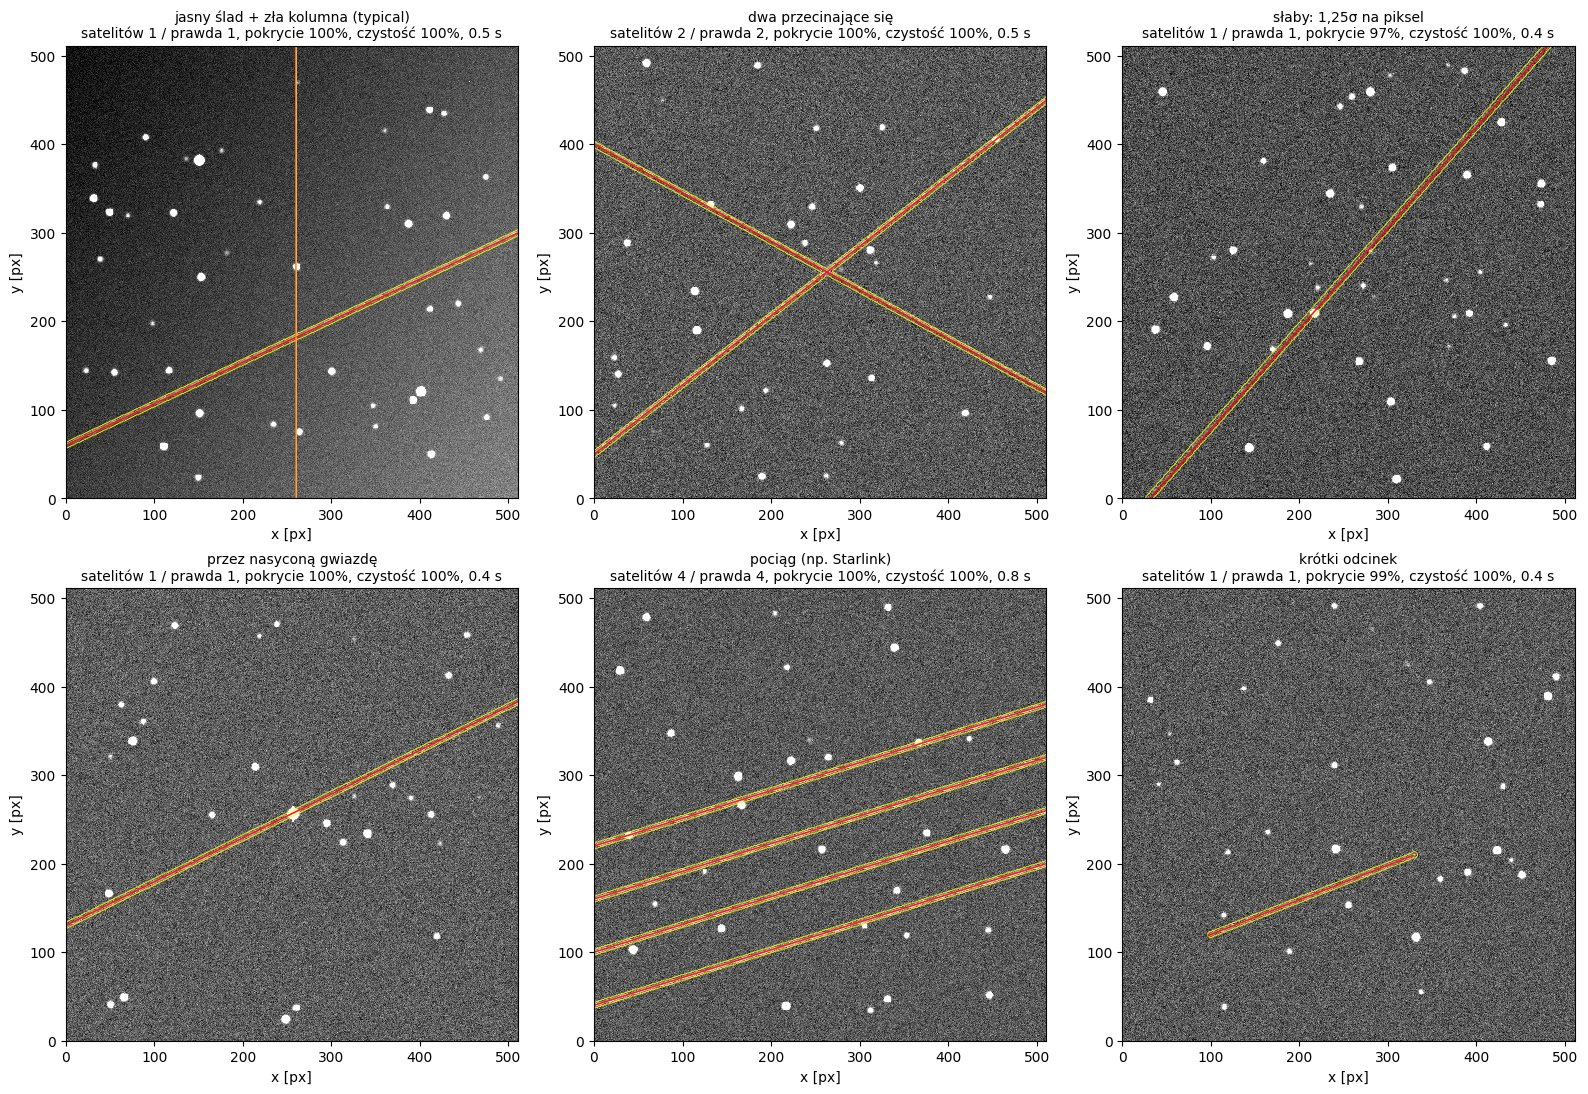

In [5]:
import time
from collections import Counter

from scipy.ndimage import binary_dilation, gaussian_filter
from pyaraucaria.satellites import find_satellites

KIND_COLORS = {"satellite": "red", "column": "tab:orange", "row": "tab:orange", "pattern": "cyan"}


def trail(x0, y0, x1, y1, flux, width=2.5):
    return dict(x0=x0, y0=y0, x1=x1, y1=y1, flux=flux, width=width)


sf = ffs_synth.star_field
mk = ffs_synth.make_frame
gallery = {
    "jasny ślad + zła kolumna (typical)": (ffs_synth.scenario("typical"), 45000),
    "dwa przecinające się": (mk(stars=sf(n=30, seed=17), sky=1000, seed=18,
                               lines=[trail(0, 50, 511, 450, 200), trail(0, 400, 511, 120, 120)]), None),
    "słaby: 1,25σ na piksel": (mk(stars=sf(n=40, seed=13), sky=1000, seed=14,
                                  lines=[trail(30, 0, 480, 511, 40, width=3.0)]), None),
    "przez nasyconą gwiazdę": (mk(stars=sf(n=30, seed=19) + [dict(x=256.4, y=256.2, flux=4e6)],
                                  sky=1000, saturation=45000, seed=20,
                                  lines=[trail(0, 130, 511, 383, 150)]), 45000),
    "pociąg (np. Starlink)": (mk(stars=sf(n=30, seed=31), sky=1000, seed=32,
                                lines=[trail(0, 40 + 60 * i, 511, 200 + 60 * i, 250) for i in range(4)]), None),
    "krótki odcinek": (mk(stars=sf(n=30, seed=15), sky=1000, seed=16,
                          lines=[trail(100, 120, 330, 210, 150)]), None),
}

results = {}
fig, axes = plt.subplots(2, 3, figsize=(16, 11))
for ax, (name, (frame, saturation)) in zip(axes.ravel(), gallery.items()):
    t0 = time.time()
    table, mask = find_satellites(frame.image, saturation=saturation)
    elapsed = time.time() - t0
    results[name] = (frame, table, mask)
    truth = frame.truth["mask_line"]
    cover = (mask & truth).sum() / max(truth.sum(), 1)
    pure = (mask & binary_dilation(truth, iterations=3)).sum() / max(mask.sum(), 1)
    show(frame.image, ax)
    ax.contour(truth, levels=[0.5], colors="yellow", linewidths=0.6)
    for r in table:
        ax.plot([r["x0"], r["x1"]], [r["y0"], r["y1"]], color=KIND_COLORS[r["kind"]], lw=1.2, alpha=0.9)
    n_sat = int(np.sum(table["kind"] == "satellite"))
    ax.set_title(f"{name}\nsatelitów {n_sat} / prawda {len(frame.truth['lines'])}, "
                 f"pokrycie {cover:.0%}, czystość {pure:.0%}, {elapsed:.1f} s", fontsize=10)
    ax.set_xlim(0, 511); ax.set_ylim(0, 511)
plt.tight_layout()

Tabela wyników dla klatki `typical`: ślad satelity i zła kolumna x = 260 (typ `column`,
nie trafia do maski). Szerokość i położenie zgadzają się z wstrzykniętymi (FWHM 2,5 px;
ślad od (0, 60) do (511, 300)).

In [6]:
frame, table, mask = results["jasny ślad + zła kolumna (typical)"]
tab = table["x0", "y0", "x1", "y1", "theta", "length", "width", "peak", "peak_snr",
            "mask_halfwidth", "significance", "kind"]
tab["theta"] = np.rad2deg(tab["theta"])
for c in tab.colnames[:-1]:
    tab[c].format = ".1f"
tab

x0,y0,x1,y1,theta,length,width,peak,peak_snr,mask_halfwidth,significance,kind
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str9
-0.5,59.8,511.5,300.2,-64.8,565.7,2.6,292.4,6.3,4.1,111.1,satellite
260.2,-0.5,260.0,511.5,0.0,512.0,1.0,401.6,8.6,2.5,41.2,column


Zbliżenie maski: ślad przechodzący przez nasyconą gwiazdę. Szerokość maski zależy od jasności
śladu (obejmuje miejsca, gdzie ślad przekracza 0,5σ szumu, co najmniej FWHM, plus margines).
Maskę podaje się do photutils, np. `aperture_photometry(data, apertures, mask=ffs.satellite_mask)`.

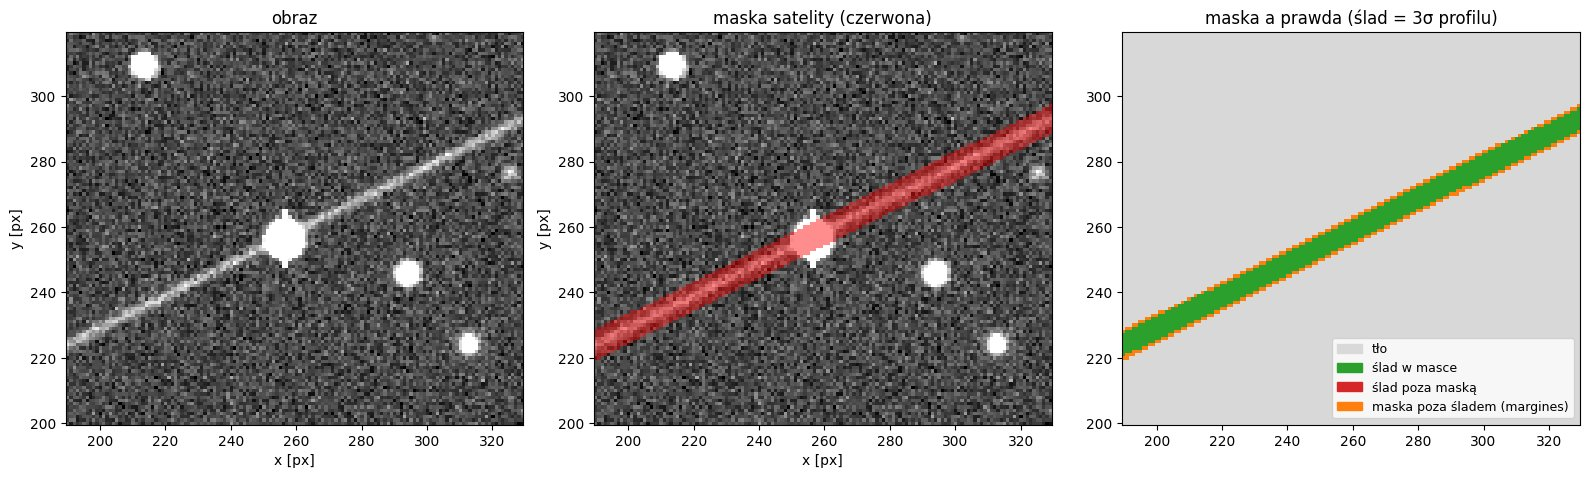

In [7]:
frame, table, mask = results["przez nasyconą gwiazdę"]
sl = (slice(200, 320), slice(190, 330))
ext = (sl[1].start - 0.5, sl[1].stop - 0.5, sl[0].start - 0.5, sl[0].stop - 0.5)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
show(frame.image[sl], axes[0], "obraz", extent=ext)
show(frame.image[sl], axes[1], "maska satelity (czerwona)", extent=ext)
axes[1].imshow(np.ma.masked_where(~mask[sl], np.ones(mask[sl].shape)), origin="lower", extent=ext,
               cmap=plt.matplotlib.colors.ListedColormap(["red"]), alpha=0.45, interpolation="nearest")
from matplotlib.patches import Patch
truth_sl, mask_sl = frame.truth["mask_line"][sl], mask[sl]
cat = np.select([truth_sl & mask_sl, truth_sl & ~mask_sl, ~truth_sl & mask_sl], [1, 2, 3], 0)
colors = ["0.85", "tab:green", "tab:red", "tab:orange"]
axes[2].imshow(cat, origin="lower", extent=ext, interpolation="nearest",
               cmap=plt.matplotlib.colors.ListedColormap(colors), vmin=-0.5, vmax=3.5)
axes[2].legend(handles=[Patch(color=c, label=l) for c, l in zip(
    colors, ["tło", "ślad w masce", "ślad poza maską", "maska poza śladem (margines)"])],
    loc="lower right", fontsize=9)
axes[2].set_title("maska a prawda (ślad = 3σ profilu)")
plt.tight_layout()

Klatki bez satelitów, które **nie** mogą dać wykrycia: zła kolumna, nasycone gwiazdy z
przelewami i słaby, okresowy wzór pasów (0,94σ na piksel — jak na prawdziwej jk15c).
Wzór jest wykrywany, ale oznaczony jako `pattern` i nie trafia do maski.

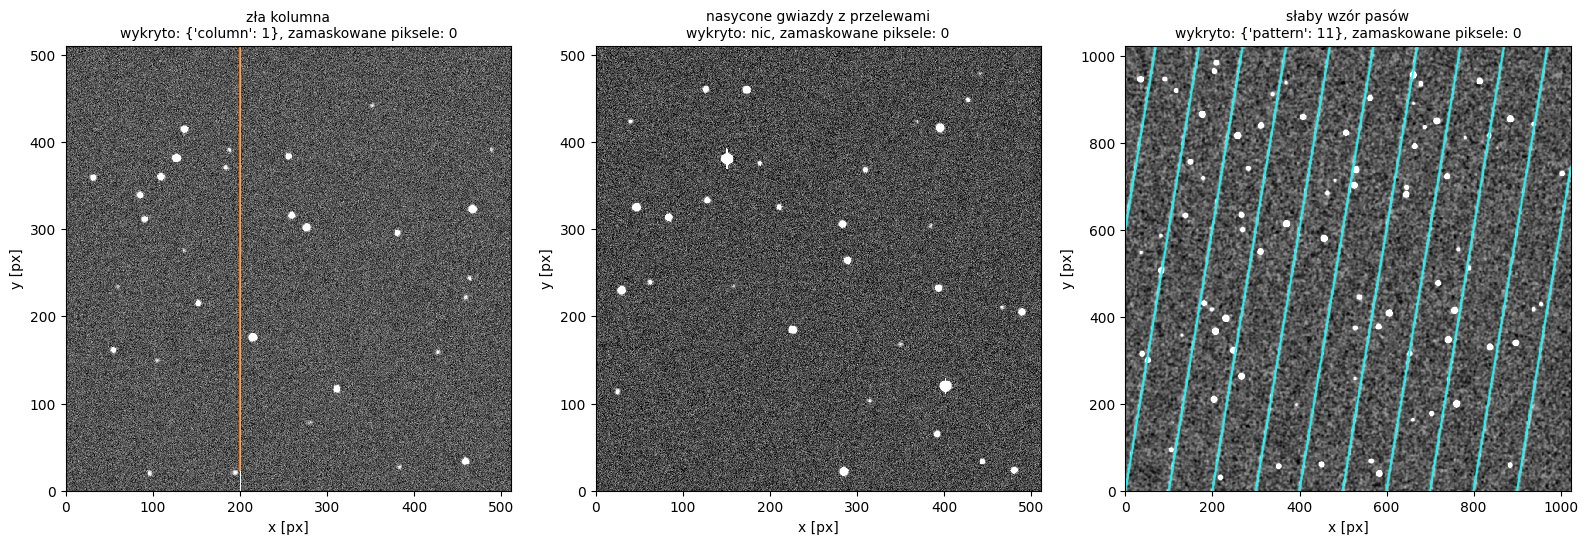

In [8]:
negatives = {
    "zła kolumna": (mk(stars=sf(n=30, seed=25), sky=1000, seed=26,
                       bad_columns=[dict(x=200, kind="hot", value=300.0)]), None, (512, 512)),
    "nasycone gwiazdy z przelewami": (mk(stars=sf(n=30, seed=27) + [dict(x=150.3, y=380.7, flux=5e6),
                                                                     dict(x=400.6, y=120.2, flux=4e6)],
                                         sky=1000, saturation=45000, seed=28), 45000, (512, 512)),
    "słaby wzór pasów": (mk(shape=(1024, 1024), stars=sf(n=80, shape=(1024, 1024), seed=33), sky=1000, seed=34,
                            lines=[trail(-200 + 100 * i, 0, -30 + 100 * i, 1023, 30.0, width=4.0)
                                   for i in range(12)]), None, (1024, 1024)),
}
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, (name, (frame, saturation, shape)) in zip(axes, negatives.items()):
    table, mask = find_satellites(frame.image, saturation=saturation)
    show(gaussian_filter(frame.image.astype(float), 2) if name == "słaby wzór pasów" else frame.image, ax)
    for r in table:
        ax.plot([r["x0"], r["x1"]], [r["y0"], r["y1"]], color=KIND_COLORS[r["kind"]], lw=1.2)
    kinds = dict(Counter(table["kind"]))
    ax.set_title(f"{name}\nwykryto: {kinds or 'nic'}, zamaskowane piksele: {mask.sum()}", fontsize=10)
    ax.set_xlim(0, shape[1] - 1); ax.set_ylim(0, shape[0] - 1)
plt.tight_layout()

## 6. Uruchomienie testów

`expected failure` oznacza znany, udokumentowany błąd, który jeszcze nie jest naprawiony
(obecnie tylko stara metoda `find_lines()`; zastępuje ją `find_satellites()`). Testy satelitów
trwają ok. pół minuty. Gdy po poprawce taki test zacznie przechodzić, unittest zgłosi
`unexpected success` — wtedy należy zdjąć dekorator.

In [9]:
import unittest

suite = unittest.TestSuite(
    unittest.defaultTestLoader.loadTestsFromName(name)
    for name in ["tests.test_ffs_truth", "tests.test_ffs_regression", "tests.test_satellites"]
)
result = unittest.TextTestRunner(verbosity=2, stream=sys.stdout).run(suite)
print()
print(f"testów: {result.testsRun}, błędy: {len(result.errors)}, porażki: {len(result.failures)}, "
      f"oczekiwane porażki: {len(result.expectedFailures)}, nieoczekiwane sukcesy: {len(result.unexpectedSuccesses)}")

test_clean_field_complete_and_pure (tests.test_ffs_truth.TestFindStars.test_clean_field_complete_and_pure) ... 

ok


test_empty_field_no_detections (tests.test_ffs_truth.TestFindStars.test_empty_field_no_detections) ... 

ok


test_hot_pixels_detected_without_filters (tests.test_ffs_truth.TestFindStars.test_hot_pixels_detected_without_filters) ... 

...

ok


test_scenarios_without_trails (tests.test_satellites.TestNoFalsePositives.test_scenarios_without_trails) ... 

ok


----------------------------------------------------------------------
Ran 53 tests in 30.818s

OK (expected failures=2)



testów: 53, błędy: 0, porażki: 0, oczekiwane porażki: 2, nieoczekiwane sukcesy: 0
